In [152]:
import re
import spacy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.parse import urlparse
import pickle
from collections import Counter
import ast
from wordcloud import WordCloud
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.stem import PorterStemmer,WordNetLemmatizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import   StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,classification_report,accuracy_score
from sklearn.metrics import  classification_report, confusion_matrix


sia = SentimentIntensityAnalyzer()
wnl = WordNetLemmatizer()
ps = PorterStemmer()
 

In [2]:
data = pd.read_json("News_Category_Dataset_v3.json",lines =True)

In [3]:
data.describe()

C:\Users\Aditi\AppData\Local\Temp\ipykernel_21452\3175101911.py:1: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  data.describe()


,link,headline,category,short_description,authors,date
count,209527,209527,209527,209527,209527,209527
unique,209486,207996,42,187022,29169,3890
top,https://www.huffingtonpost.comhttps://www.wash...,Sunday Roundup,POLITICS,,,2014-03-25 00:00:00
freq,2,90,35602,19712,37418,100
first,NaN,NaN,NaN,NaN,NaN,2012-01-28 00:00:00
last,NaN,NaN,NaN,NaN,NaN,2022-09-23 00:00:00


In [4]:
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209527 entries, 0 to 209526
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   link               209527 non-null  object        
 1   headline           209527 non-null  object        
 2   category           209527 non-null  object        
 3   short_description  209527 non-null  object        
 4   authors            209527 non-null  object        
 5   date               209527 non-null  datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 9.6+ MB


,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


Preprocess
1. remove duplicates
2. fill missing


In [5]:
data.duplicated().sum()
data.drop_duplicates(inplace=True)

In [6]:
data.isnull().sum()

link                 0
headline             0
category             0
short_description    0
authors              0
date                 0
dtype: int64

3. link to source

In [7]:
def get_source_website(url):
    parsed_url = urlparse(url)
    domain = parsed_url.netloc
    # Remove 'www.' prefix if it exists
    if domain.startswith('www.'):
        domain = domain[4:]
    # Get the base domain
    source_website = domain.split('.')[0]
    return source_website

# Apply the function to the 'link' column
data['source_website'] = data['link'].apply(get_source_website)
data.drop(columns='link',inplace=True)

<Axes: xlabel='count', ylabel='source_website'>

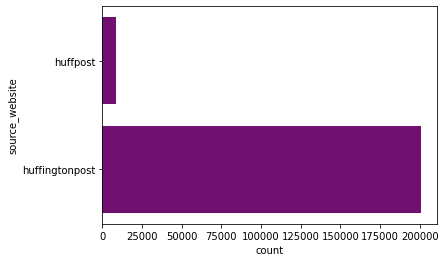

In [16]:
sns.countplot(data['source_website'],color='purple')

4. merge categories


In [10]:
data.category.value_counts()

POLITICS          35601
WELLNESS          17942
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9811
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
COMEDY             5400
SPORTS             5077
BLACK VOICES       4583
HOME & LIVING      4320
PARENTS            3955
THE WORLDPOST      3664
WEDDINGS           3653
WOMEN              3571
CRIME              3562
IMPACT             3484
DIVORCE            3426
WORLD NEWS         3299
MEDIA              2944
WEIRD NEWS         2777
GREEN              2622
WORLDPOST          2579
RELIGION           2577
STYLE              2254
SCIENCE            2206
TECH               2100
TASTE              2096
MONEY              1756
ARTS               1509
ENVIRONMENT        1443
FIFTY              1401
GOOD NEWS          1398
U.S. NEWS          1377
ARTS & CULTURE     1339
COLLEGE            1144
LATINO VOICES      1130
CULTURE & ARTS     1074
EDUCATION       

In [11]:
# merge categories
data['category'] = data['category'].replace({"HEALTHY LIVING": "LIFESTYLE",
"QUEER VOICES": "GROUPS VOICES",
"BUSINESS": "BUSINESS & FINANCES",
"PARENTS": "PARENTING",
"BLACK VOICES": "GROUPS VOICES",
"THE WORLDPOST": "WORLD NEWS",
"STYLE": "HEALTH & BEAUTY",
"GREEN": "ENVIRONMENT",
"TASTE": "FOOD & TRAVEL",
"WORLDPOST": "WORLD NEWS",
"SCIENCE": "SCIENCE & TECH",
"TECH": "SCIENCE & TECH",
"MONEY": "BUSINESS & FINANCES",
"ARTS": "ARTS & CULTURE",
"COLLEGE": "EDUCATION",
"LATINO VOICES": "GROUPS VOICES",
"CULTURE & ARTS": "ARTS & CULTURE",
"FIFTY": "MISCELLANEOUS",
"GOOD NEWS": "MISCELLANEOUS",
"TRAVEL":"FOOD & TRAVEL",
"STYLE & BEAUTY":"HEALTH & BEAUTY",
"WELLNESS": "HEALTH & BEAUTY",
    'COMEDY':'ENTERTAINMENT',
    'SPORTS':'ENTERTAINMENT',
    'HOME & LIVING':'LIFESTYLE',
    'PARENTING':'RELATIONSHIPS',
    'WEDDINGS':'RELATIONSHIPS',
    'DIVORCE':'RELATIONSHIPS',
    'ARTS & CULTURE':'ENTERTAINMENT',
    'WOMEN':'OPINION/EDITORIAL',
    'IMPACT':'OPINION/EDITORIAL',
    'MEDIA':'ENTERTAINMENT',
    'WEIRD NEWS':'MISCELLANEOUS',
    'RELIGION':'RELIGIOUS',
    'U.S. NEWS':'WORLD NEWS',
    'FOOD & DRINK':'FOOD & TRAVEL',})

C:\Users\Aditi\AppData\Local\Temp\ipykernel_21452\1878180873.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data['category'], palette='viridis')


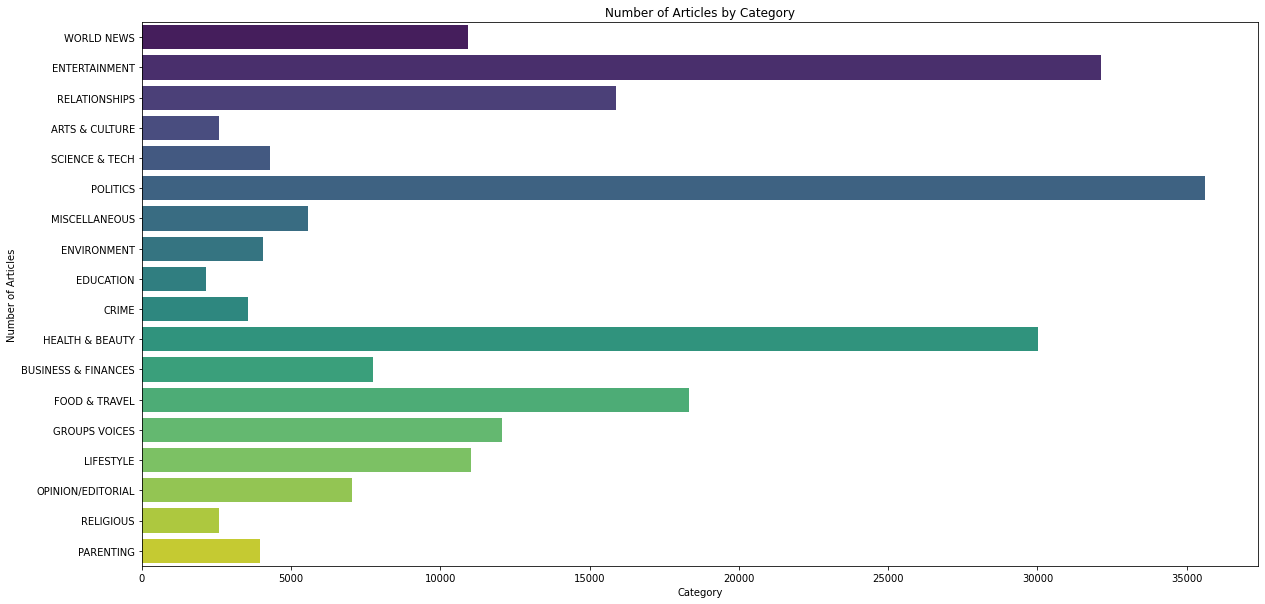

In [12]:
plt.figure(figsize=(20, 10))
sns.countplot(data['category'], palette='viridis')
plt.title('Number of Articles by Category')
plt.xlabel('Category')
plt.ylabel('Number of Articles')
plt.show()

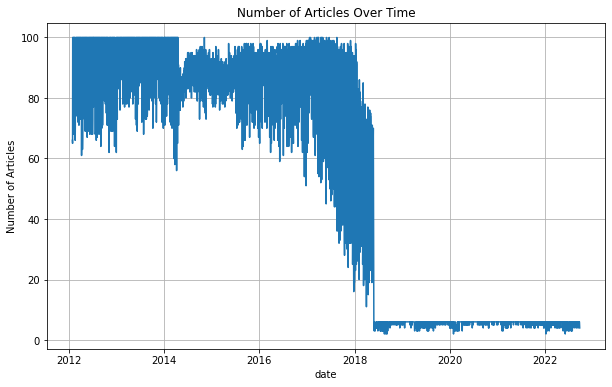

In [ ]:

data['date'] = pd.to_datetime(data['date'])

articles_over_time = data.groupby(data['date'].dt.date).size()

plt.figure(figsize=(10, 6),)
articles_over_time.plot(kind='line')
plt.title('Number of Articles Over Time')
plt.xlabel('date')
plt.ylabel('Number of Articles')
plt.grid(True)
plt.show()

In [20]:
data.columns

Index(['headline', 'category', 'short_description', 'authors', 'date',
       'source_website'],
      dtype='object')

In [13]:
#data.drop(columns=['date','source_website'],inplace= True)

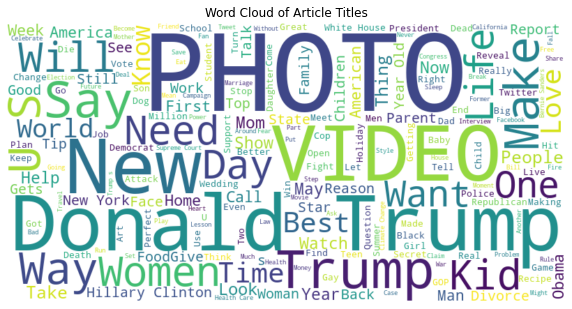

In [22]:
text = ' '.join(data['headline'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Article Titles')
plt.show()

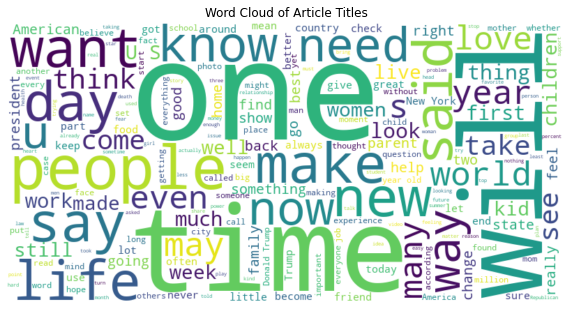

In [24]:
text = ' '.join(data['short_description'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Article Titles')
plt.show()

In [25]:
data['short_description'] = data['short_description'].str.lower()
data["short_description"] = data["short_description"].apply(lambda x: re.sub(r'[^a-zA-Z\s]', " ", x))
#data['short_description'].tail()

In [26]:
data['headline'] = data['headline'].str.lower()
data["headline"] = data["headline"].apply(lambda x: re.sub(r'[^a-zA-Z\s]', " ", x))
#data['headline'].tail()

In [ ]:
#nltk.download('all')

In [27]:
data['token_desc'] = data['short_description'].apply(lambda x: nltk.word_tokenize(x))
data['token_headline'] = data['headline'].apply(lambda x: nltk.word_tokenize(x))

In [28]:
stopwords = nltk.corpus.stopwords.words('english')
data['token_desc'] = data['token_desc'].apply(lambda x: [w for w in x if w.lower() not in stopwords] )
data['token_headline'] = data['token_headline'].apply(lambda x: [w for w in x if w.lower() not in stopwords] )

In [29]:
data.head()

,headline,category,short_description,authors,date,source_website,token_desc,token_headline
0,over million americans roll up sleeves for o...,WORLD NEWS,health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23,huffpost,"[health, experts, said, early, predict, whethe...","[million, americans, roll, sleeves, omicron, t..."
1,american airlines flyer charged banned for li...,WORLD NEWS,he was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23,huffpost,"[subdued, passengers, crew, fled, back, aircra...","[american, airlines, flyer, charged, banned, l..."
2,of the funniest tweets about cats and dogs ...,ENTERTAINMENT,until you have a dog you don t understand wha...,Elyse Wanshel,2022-09-23,huffpost,"[dog, understand, could, eaten]","[funniest, tweets, cats, dogs, week, sept]"
3,the funniest tweets from parents this week se...,RELATIONSHIPS,accidentally put grown up toothpaste on my to...,Caroline Bologna,2022-09-23,huffpost,"[accidentally, put, grown, toothpaste, toddler...","[funniest, tweets, parents, week, sept]"
4,woman who called cops on black bird watcher lo...,WORLD NEWS,amy cooper accused investment firm franklin te...,Nina Golgowski,2022-09-22,huffpost,"[amy, cooper, accused, investment, firm, frank...","[woman, called, cops, black, bird, watcher, lo..."


% sentiment

a. sentiment
b. summarize

In [22]:
# polarity scores to trial and error with the compund score
# text2 = data['short_description'].apply(lambda x:sia.polarity_scores(x))
# df_senti_desc = pd.json_normalize(text2)
# print(df_senti_desc)
# print(df_senti_desc.describe())

In [123]:
def label_sentiment(text):
    scores = sia.polarity_scores(text)
    compound_score = scores['compound']
     
    if compound_score > 0.5:
        return 1
    elif compound_score < -0.5:
        return -1
    else:
        return 0
        

In [124]:
data['sentiment'] = data['short_description'].apply(lambda x: label_sentiment(x))
data['sentiment'].value_counts()

 0    116007
 1     39277
-1     18393
Name: sentiment, dtype: int64

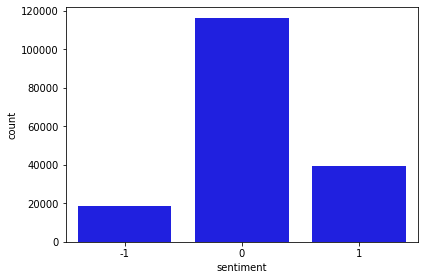

In [98]:
sns.countplot( data=data, x='sentiment',color='blue')

plt.tight_layout()
plt.show()

In [26]:
data.dropna(inplace=True)

In [27]:
#data.drop(columns=['short_description','headline'],inplace = True)

In [35]:
top_9_categories = data['category'].value_counts().nlargest(9).index

# Step 2: Filter the DataFrame to include only rows that belong to the top 9 categories
data = data[data['category'].isin(top_9_categories)]
data['category'].value_counts(sort=True,ascending=False)

POLITICS               35601
ENTERTAINMENT          32122
HEALTH & BEAUTY        30007
FOOD & TRAVEL          18336
RELATIONSHIPS          15870
GROUPS VOICES          12060
LIFESTYLE              11014
WORLD NEWS             10919
BUSINESS & FINANCES     7748
Name: category, dtype: int64

In [32]:
#spacy.cli.download("en_core_web_lg")

In [37]:
# already run
ner = spacy.load("en_core_web_lg")
data["tags"] = data['token_desc'].apply(lambda x: [(tag.text, tag.label_) for text in x for tag in ner(text).ents])

In [38]:
print(data['tags'].head())

0                                [(million, CARDINAL)]
1                                     [(angeles, GPE)]
2                                                   []
3                    [(carolina, GPE), (tabasco, ORG)]
4    [(amy, PERSON), (cooper, ORG), (franklin, ORG)...
Name: tags, dtype: object


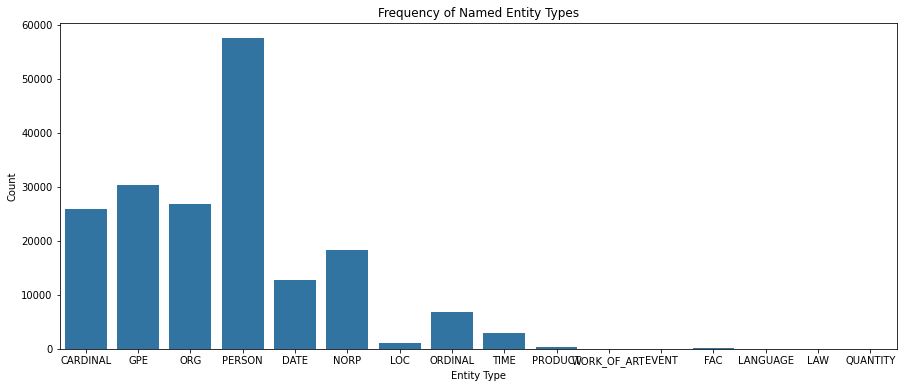

In [39]:
all_entities = [entity for sublist in data['tags'] for entity in sublist]
entity_types = [entity_type for _, entity_type in all_entities]

entity_counts = Counter(entity_types)

entity_counts_df = pd.DataFrame.from_dict(entity_counts, orient='index', columns=['count']).reset_index()
entity_counts_df.rename(columns={'index': 'entity_type'}, inplace=True)


plt.figure(figsize=(15, 6))
sns.barplot(data=entity_counts_df, x='entity_type', y='count')
plt.title('Frequency of Named Entity Types')
plt.xlabel('Entity Type')
plt.ylabel('Count')
plt.show()

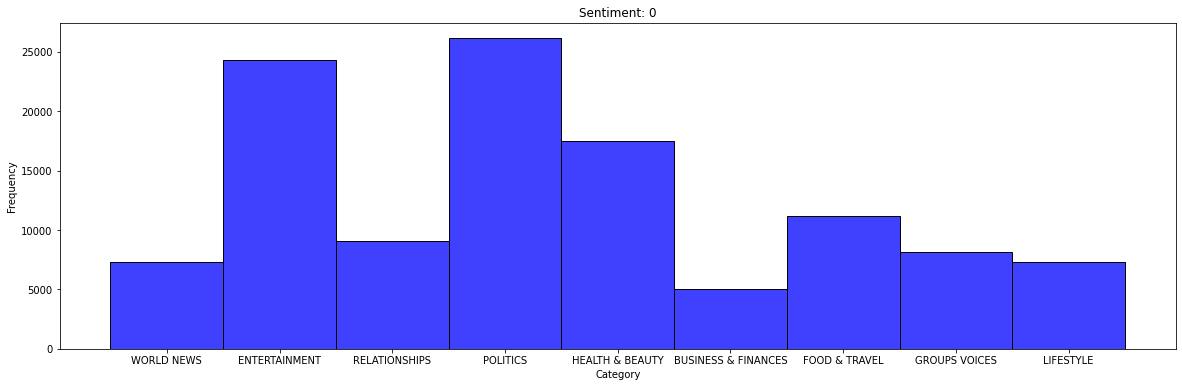

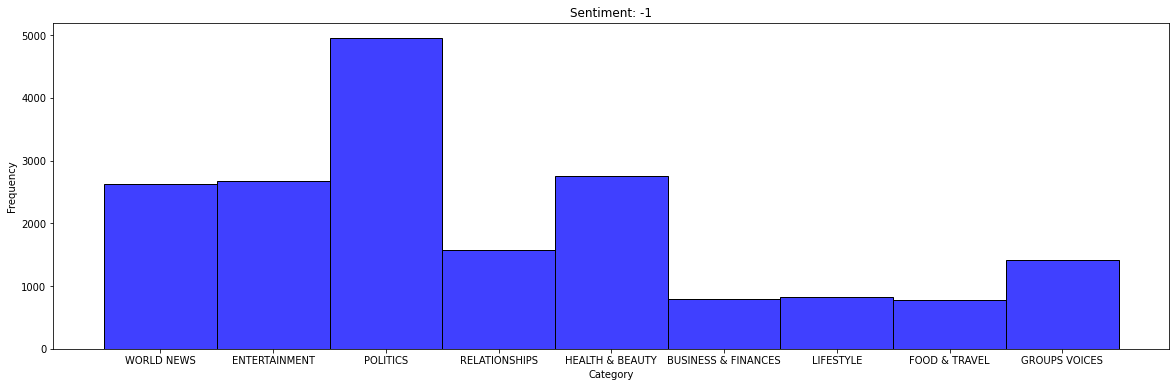

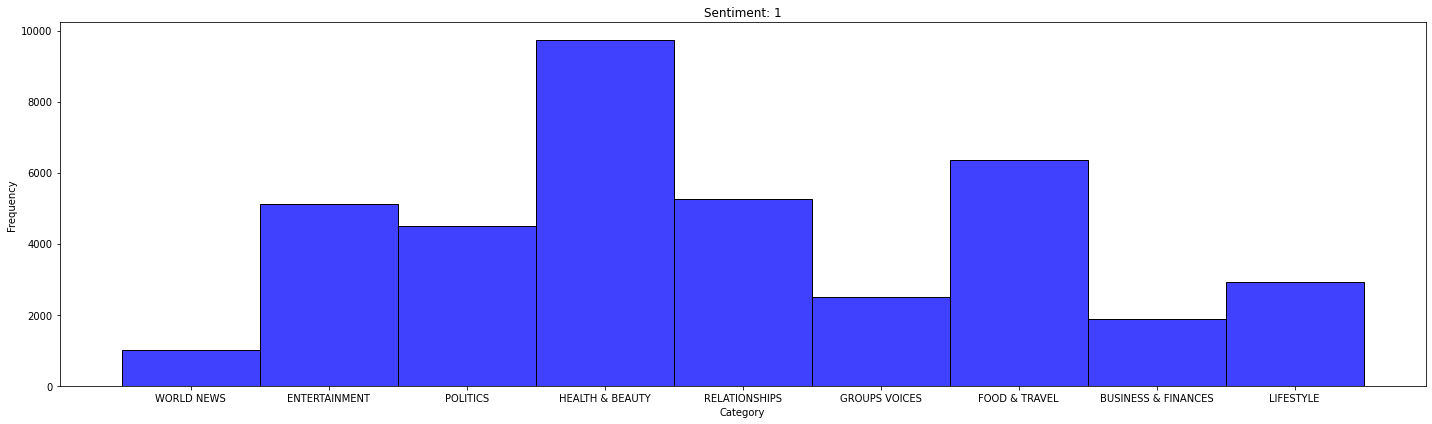

In [126]:
sentiments = data['sentiment'].unique()
for i, sentiment in enumerate(sentiments, 1):
    plt.figure(figsize=(20,6))
    sns.histplot(data=data[data['sentiment'] == sentiment], x='category', discrete=True,color='blue')
    plt.title(f'Sentiment: {sentiment}')
    plt.xlabel('Category')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [44]:
data['Pos_headline'] =  data['token_headline'].apply(lambda x: nltk.pos_tag(x))
data['Pos'] =  data['token_desc'].apply(lambda x: nltk.pos_tag(x))

In [45]:
data['lemm'] = data['token_desc'].apply(lambda x: [wnl.lemmatize(token) for token in x])

In [46]:
data['stem'] = data['token_desc'].apply(lambda x: [ps.stem(token) for token in x])

In [47]:
data['lemm_headline'] = data['token_headline'].apply(lambda x: [wnl.lemmatize(token) for token in x])
data['stem_headline'] = data['token_headline'].apply(lambda x: [ps.stem(token) for token in x])

In [97]:
data.head()

,headline,category,short_description,authors,token_desc,token_headline,sentiment,tags,Pos,lemm,stem,lemm_headline,stem_headline,Pos_headline
0,over million americans roll up sleeves for o...,WORLD NEWS,health experts said it is too early to predict...,"Carla K. Johnson, AP","[health, experts, said, early, predict, whethe...","[million, americans, roll, sleeves, omicron, t...",negative,"[(million, CARDINAL)]","[(health, NN), (experts, NNS), (said, VBD), (e...","[health, expert, said, early, predict, whether...","[health, expert, said, earli, predict, whether...","[million, american, roll, sleeve, omicron, tar...","[million, american, roll, sleev, omicron, targ...","[(million, CD), (americans, NNS), (roll, VBP),..."
1,american airlines flyer charged banned for li...,WORLD NEWS,he was subdued by passengers and crew when he ...,Mary Papenfuss,"[subdued, passengers, crew, fled, back, aircra...","[american, airlines, flyer, charged, banned, l...",negative,"[(angeles, GPE)]","[(subdued, VBN), (passengers, NNS), (crew, VBD...","[subdued, passenger, crew, fled, back, aircraf...","[subdu, passeng, crew, fled, back, aircraft, c...","[american, airline, flyer, charged, banned, li...","[american, airlin, flyer, charg, ban, life, pu...","[(american, JJ), (airlines, NNS), (flyer, RB),..."
2,of the funniest tweets about cats and dogs ...,ENTERTAINMENT,until you have a dog you don t understand wha...,Elyse Wanshel,"[dog, understand, could, eaten]","[funniest, tweets, cats, dogs, week, sept]",neutral,[],"[(dog, NN), (understand, NN), (could, MD), (ea...","[dog, understand, could, eaten]","[dog, understand, could, eaten]","[funniest, tweet, cat, dog, week, sept]","[funniest, tweet, cat, dog, week, sept]","[(funniest, JJS), (tweets, NNS), (cats, NNS), ..."
3,the funniest tweets from parents this week se...,RELATIONSHIPS,accidentally put grown up toothpaste on my to...,Caroline Bologna,"[accidentally, put, grown, toothpaste, toddler...","[funniest, tweets, parents, week, sept]",negative,"[(carolina, GPE), (tabasco, ORG)]","[(accidentally, RB), (put, VBD), (grown, JJ), ...","[accidentally, put, grown, toothpaste, toddler...","[accident, put, grown, toothpast, toddler, too...","[funniest, tweet, parent, week, sept]","[funniest, tweet, parent, week, sept]","[(funniest, JJS), (tweets, NNS), (parents, NNS..."
4,woman who called cops on black bird watcher lo...,WORLD NEWS,amy cooper accused investment firm franklin te...,Nina Golgowski,"[amy, cooper, accused, investment, firm, frank...","[woman, called, cops, black, bird, watcher, lo...",negative,"[(amy, PERSON), (cooper, ORG), (franklin, ORG)...","[(amy, JJ), (cooper, NN), (accused, VBN), (inv...","[amy, cooper, accused, investment, firm, frank...","[ami, cooper, accus, invest, firm, franklin, t...","[woman, called, cop, black, bird, watcher, los...","[woman, call, cop, black, bird, watcher, lose,...","[(woman, NN), (called, VBN), (cops, NNS), (bla..."


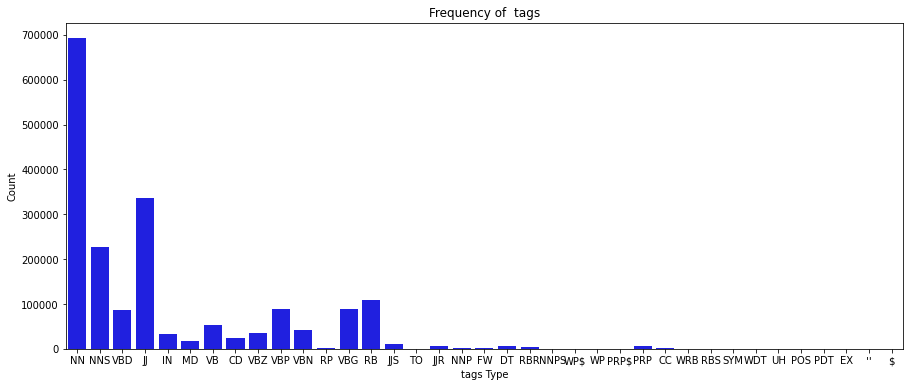

In [101]:

all_entities = [tags for sublist in data['Pos'] for tags in sublist]
tags_types = [tags_type for _, tags_type in all_entities]

tags_counts = Counter(tags_types)

tags_counts_df = pd.DataFrame.from_dict(tags_counts, orient='index', columns=['count']).reset_index()
tags_counts_df.rename(columns={'index': 'tags_type'}, inplace=True)

plt.figure(figsize=(15, 6))
sns.barplot(data=tags_counts_df, x='tags_type', y='count',color='Blue')
plt.title('Frequency of  tags')
plt.xlabel('tags Type')
plt.ylabel('Count')
plt.show()

In [48]:
data.to_pickle("data_pos_lem_stem.pkl")

In [66]:
data=pd.read_pickle("data_pos_lem_stem.pkl")

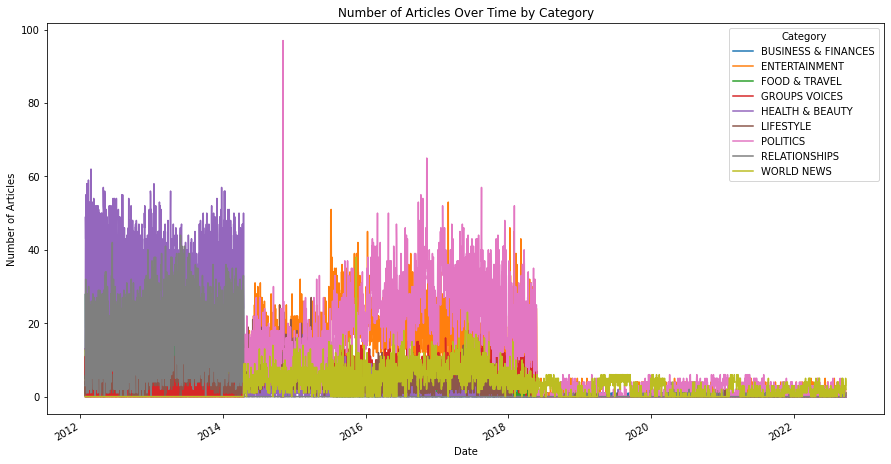

In [67]:
data['date'] = pd.to_datetime(data['date'])

grouped_data = data.groupby(['date', 'category']).size().reset_index(name='count')

pivot_table = grouped_data.pivot(index='date', columns='category', values='count').fillna(0)


plt.figure(figsize=(15, 8))
pivot_table.plot(kind='line', ax=plt.gca())
plt.title('Number of Articles Over Time by Category')
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.legend(title='Category')
plt.show()

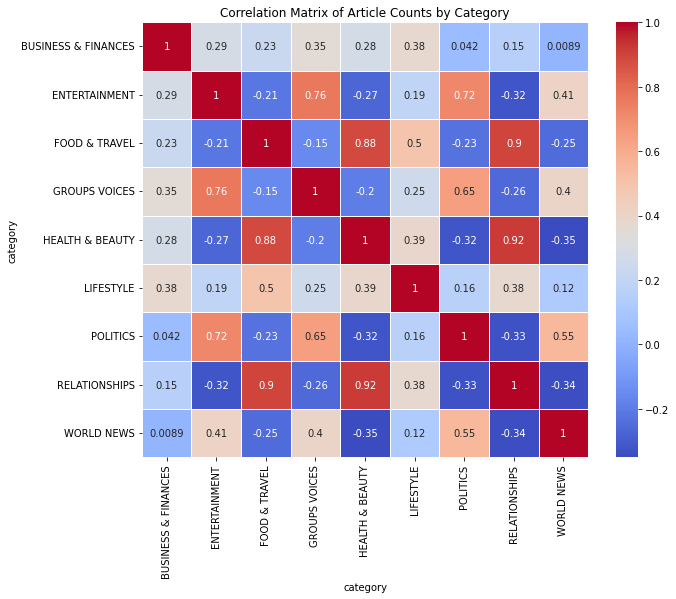

In [68]:
data['date'] = pd.to_datetime(data['date'])

grouped_data = data.groupby(['date', 'category']).size().reset_index(name='count')

pivot_table = grouped_data.pivot(index='date', columns='category', values='count').fillna(0)

correlation_matrix = pivot_table.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Article Counts by Category')
plt.show()


In [127]:
data['full_news']  = data['headline'] + data['short_description']
data['full_news'].isnull().sum()

0

In [ ]:
# data['full_news'] = data['full_news'].str.lower()
# data["full_news"] = data["full_news"].apply(lambda x: re.sub(r'[^a-zA-Z\s]', " ", x))
# data['full_news'] = data['full_news'].apply(lambda x: nltk.word_tokenize(x))
# data['full_news'] = data['full_news'].apply(lambda x: [w for w in x if w.lower() not in stopwords] )
# data['sentiment'] = data['full_news'].apply(lambda x: sia_on_tokenized(x))
# data['sentiment'].head()
# data['full_news'].tail()

209522    [rim, ceo, thorsten, heins, significant, plans...
209523    [maria, sharapova, stunned, by, victoria, azar...
209524    [giants, over, patriots, jets, over, colts, am...
209525    [aldon, smith, arrested, ers, linebacker, bust...
209526    [dwight, howard, rips, teammates, after, magic...
Name: full_news, dtype: object

In [ ]:
#data = pd.read_excel("C:/Users/Aditi/OneDrive/Desktop/Data Analysis/Internship/inshorts/sia.xlsx")

In [130]:
data = pd.read_pickle("data_final.pkl")

In [132]:

positive_data = data[data['sentiment_full'] == 'positive'].head(3500)
neutral_data = data[data['sentiment_full'] == 'neutral'].head(3500)
negative_data = data[data['sentiment_full'] == 'negative'].head(3500)

# Concatenate 
final_data = pd.concat([positive_data, neutral_data, negative_data])

# Shuffle 
final_data = final_data.sample(frac=1).reset_index(drop=True)


In [133]:
final_data.columns

Index(['headline', 'category', 'short_description', 'authors', 'date',
       'source_website', 'token_desc', 'token_headline', 'sentiment', 'tags',
       'Pos_headline', 'Pos', 'lemm', 'stem', 'lemm_headline', 'stem_headline',
       'sentiment_full', 'full_news'],
      dtype='object')

In [134]:
final_data.drop(columns=['category','authors','date','source_website','tags','Pos_headline','Pos','lemm','lemm_headline','stem','stem_headline','sentiment'],inplace = True)
#final_data.drop(columns=['Unnamed: 0','link','news_len'],inplace=True)


In [136]:
final_data.drop(columns='sentiment',inplace=True)

In [137]:
final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9621 entries, 0 to 9620
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   headline           9621 non-null   object
 1   short_description  9621 non-null   object
 2   token_desc         9621 non-null   object
 3   token_headline     9621 non-null   object
 4   sentiment_full     9621 non-null   object
 5   full_news          9621 non-null   object
dtypes: object(6)
memory usage: 451.1+ KB


In [138]:
y= final_data['sentiment_full']

final_data.drop(columns=['sentiment_full'],inplace=True)


<Axes: xlabel='sentiment_full', ylabel='Count'>

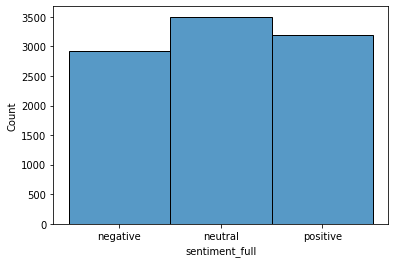

In [139]:
sns.histplot(y,)

In [140]:
X_train,X_test,y_train,y_test = train_test_split(final_data['full_news'],y,test_size=0.2,random_state=0)

In [141]:
vectorizer2 = CountVectorizer()
X_train_cv = vectorizer2.fit_transform(X_train)
X_test_cv = vectorizer2.transform(X_test)

In [ ]:
#standardise

std = StandardScaler(with_mean=False)
std.fit_transform(X_train_cv)
std.transform(X_test_cv)

<2100x26198 sparse matrix of type '<class 'numpy.float64'>'
	with 32062 stored elements in Compressed Sparse Row format>

In [144]:
multi= SGDClassifier()
multi.fit(X_train_cv, y_train)

y_pred = multi.predict(X_test_cv)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Classification Report:\n{report}")
print(f"Confusion Matrix:\n{conf_matrix}")

Accuracy: 0.7958441558441558
Classification Report:
              precision    recall  f1-score   support

    negative       0.73      0.74      0.74       565
     neutral       0.84      0.80      0.82       708
    positive       0.80      0.83      0.82       652

    accuracy                           0.80      1925
   macro avg       0.79      0.79      0.79      1925
weighted avg       0.80      0.80      0.80      1925

Confusion Matrix:
[[419  66  80]
 [ 87 569  52]
 [ 65  43 544]]


Logistic Regression Cross-Validation Accuracy: 0.7996346084065382
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00      2362
     neutral       1.00      1.00      1.00      2792
    positive       1.00      1.00      1.00      2542

    accuracy                           1.00      7696
   macro avg       1.00      1.00      1.00      7696
weighted avg       1.00      1.00      1.00      7696



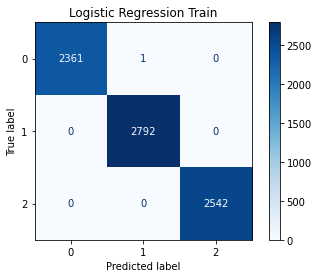

              precision    recall  f1-score   support

    negative       0.75      0.77      0.76       565
     neutral       0.85      0.82      0.83       708
    positive       0.83      0.84      0.83       652

    accuracy                           0.81      1925
   macro avg       0.81      0.81      0.81      1925
weighted avg       0.81      0.81      0.81      1925



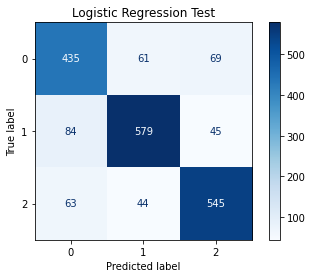

KNN Cross-Validation Accuracy: 0.41866653164898776
              precision    recall  f1-score   support

    negative       0.77      0.90      0.83      2362
     neutral       0.98      0.81      0.89      2792
    positive       0.86      0.89      0.87      2542

    accuracy                           0.86      7696
   macro avg       0.87      0.87      0.86      7696
weighted avg       0.88      0.86      0.87      7696



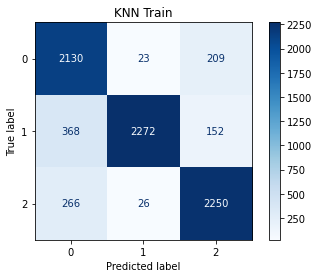

              precision    recall  f1-score   support

    negative       0.40      0.39      0.40       565
     neutral       0.72      0.11      0.19       708
    positive       0.40      0.78      0.53       652

    accuracy                           0.42      1925
   macro avg       0.51      0.43      0.37      1925
weighted avg       0.52      0.42      0.37      1925



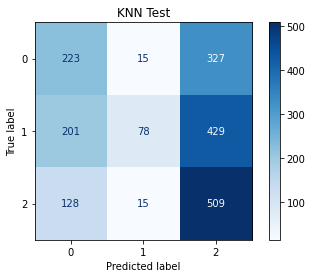

Poly_SVC Cross-Validation Accuracy: 0.7915786098242238
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00      2362
     neutral       1.00      1.00      1.00      2792
    positive       1.00      1.00      1.00      2542

    accuracy                           1.00      7696
   macro avg       1.00      1.00      1.00      7696
weighted avg       1.00      1.00      1.00      7696



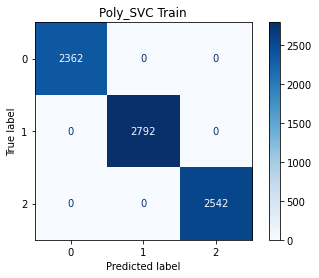

              precision    recall  f1-score   support

    negative       0.74      0.76      0.75       565
     neutral       0.85      0.78      0.81       708
    positive       0.80      0.84      0.82       652

    accuracy                           0.79      1925
   macro avg       0.79      0.79      0.79      1925
weighted avg       0.80      0.79      0.79      1925



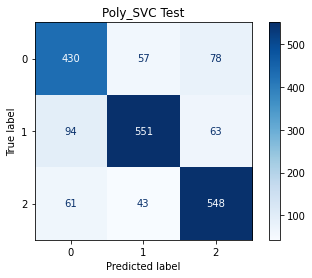

sgd Cross-Validation Accuracy: 0.7880708505269908
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00      2362
     neutral       1.00      1.00      1.00      2792
    positive       1.00      1.00      1.00      2542

    accuracy                           1.00      7696
   macro avg       1.00      1.00      1.00      7696
weighted avg       1.00      1.00      1.00      7696



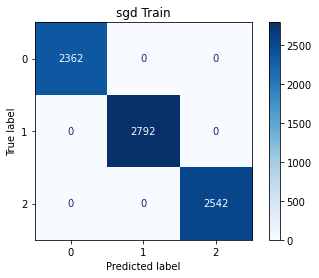

              precision    recall  f1-score   support

    negative       0.73      0.74      0.73       565
     neutral       0.82      0.82      0.82       708
    positive       0.82      0.82      0.82       652

    accuracy                           0.79      1925
   macro avg       0.79      0.79      0.79      1925
weighted avg       0.79      0.79      0.79      1925



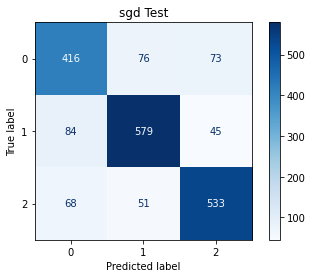

rf Cross-Validation Accuracy: 0.7758580795422901
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00      2362
     neutral       1.00      1.00      1.00      2792
    positive       1.00      1.00      1.00      2542

    accuracy                           1.00      7696
   macro avg       1.00      1.00      1.00      7696
weighted avg       1.00      1.00      1.00      7696



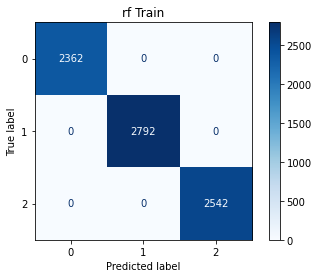

              precision    recall  f1-score   support

    negative       0.75      0.70      0.73       565
     neutral       0.82      0.79      0.80       708
    positive       0.77      0.84      0.81       652

    accuracy                           0.78      1925
   macro avg       0.78      0.78      0.78      1925
weighted avg       0.78      0.78      0.78      1925



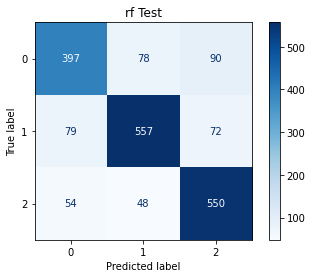

In [154]:
classifiers = {
    'Logistic Regression': LogisticRegression(random_state=42),#maximum likelihood  
    'KNN':KNeighborsClassifier(n_neighbors=3),
    'Poly_SVC': SVC(kernel="poly", degree=3, coef0=1, C=5),
    'sgd': SGDClassifier(),
    'rf': RandomForestClassifier(),
}

# Iterate over classifiers and perform cross-validation
for clf_name, clf in classifiers.items():
    pipeline = Pipeline([
        ('classifier', clf)
    ])
    # Perform cross-validation on the training set
    scores = cross_val_score(pipeline, X_train_cv, y_train, cv=5)
    print(f'{clf_name} Cross-Validation Accuracy: {scores.mean()}')

    # Fitting the classifier to the training data
    pipeline.fit(X_train_cv, y_train)

    # Predict on train and test set
    y_train_pred = pipeline.predict(X_train_cv)
    y_pred = pipeline.predict(X_test_cv)

    
    # Performance and confusion  matrix
    print(classification_report(y_train, y_train_pred)) 
    cm_train = confusion_matrix(y_train,y_train_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_train)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'{clf_name} Train')
    plt.show()

    print(classification_report(y_test,y_pred))
    cm_test = confusion_matrix(y_test,y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_test)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'{clf_name} Test')
    plt.show()


    #save models
    # models created
    #model_filename = f'{clf_name.replace(" ", "_")}_model.pkl'
    #with open(model_filename, 'wb') as file:
        #pickle.dump(clf,file)


#load model
#model_filename =path/to/model
# pickled_model = pickle.load(open(model_filename, 'rb'))
#pickled_model.predict(x_test)
